In [55]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from datetime import datetime, date, timedelta

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import holidays
from sklearn.metrics import mean_absolute_percentage_error, root_mean_squared_log_error

import warnings
warnings.filterwarnings("ignore")

In [56]:
plt.style.use('ggplot')
plt.style.use('fivethirtyeight')

In [57]:
def mean_absolute_percentage_error(actual, pred):
    """Mean Absolute Percentage Error"""
    actual, pred = np.array(actual), np.array(pred)
    return np.mean(np.abs((actual - pred) / actual)) * 100

Using hourly power consumptino data from PJME from 2002-2018

In [58]:
pjme = pd.read_csv('./csvs/PJME_hourly.csv', index_col=[0] ,parse_dates=[0])
pjme

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0
...,...
2018-01-01 20:00:00,44284.0
2018-01-01 21:00:00,43751.0
2018-01-01 22:00:00,42402.0


In [59]:
print(type(pjme))
print(pjme.columns)

<class 'pandas.core.frame.DataFrame'>
Index(['PJME_MW'], dtype='object')


In [60]:
# pjme.set_index('Datetime', inplace=True)

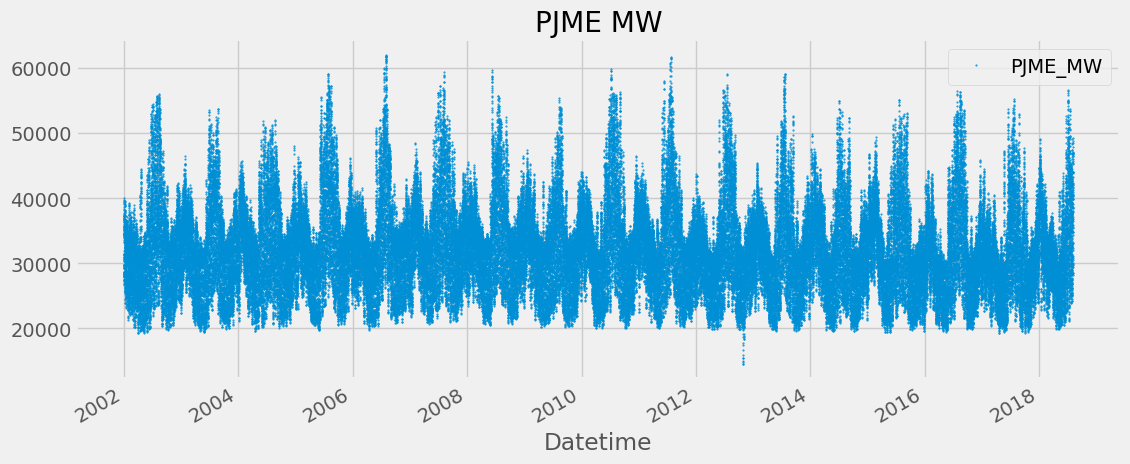

In [61]:
pjme.plot(figsize=(12,5), style='.', ms=1, title="PJME MW")
plt.show()

# Time Series Features

In [62]:
from pandas.api.types import CategoricalDtype

cat_type = CategoricalDtype(categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], ordered=True)


def create_features(df, label=None):
    '''Create time series features from Datetime'''
    df = df.copy()
    df['date'] = df.index
    df['hour'] = df['date'].dt.hour
    df['dayofweek'] = df['date'].dt.dayofweek
    df['weekday'] = df['date'].dt.weekday
    df['weekend'] = df['weekday'].astype(cat_type)
    df['dayofyear'] = df['date'].dt.dayofyear
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['quarter'] = df['date'].dt.quarter
    df['dayofmonth'] = df['date'].dt.day
    # df['weekofyear'] = df['date'].dt.weekofyear
    df['date_offset'] = (df.date.dt.month * 100 + df.date.dt.day - 320)%1300
    
    df['season'] = pd.cut(df['date_offset'], [0, 300, 602, 900, 1300], labels=['Spring', "Summer", "Fall", "Winter"])
    
    X = df[['hour', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'dayofmonth', 'weekday', 'season']]
    if label:
        y = df[label]
        return X, y
    return X
X, y =  create_features(pjme, label="PJME_MW")
features_and_target = pd.concat([X, y], axis=1)

In [63]:
# df = pjme.copy()
# df['date'] = df.index
# df['hour'] = df['date'].dt.hour
# df['weekday'] = df['date'].dt.dayofyear
# df['weekend'] = df['weekday'].astype(cat_type)
# df['date_offset'] = df['date'].dt.weekofyear()
# df.date_offset

In [64]:
features_and_target

,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekday,season,PJME_MW
Datetime,,,,,,,,,,
2002-12-31 01:00:00,1,1,4,12,2002,365,31,1,Winter,26498.0
2002-12-31 02:00:00,2,1,4,12,2002,365,31,1,Winter,25147.0
2002-12-31 03:00:00,3,1,4,12,2002,365,31,1,Winter,24574.0
2002-12-31 04:00:00,4,1,4,12,2002,365,31,1,Winter,24393.0
2002-12-31 05:00:00,5,1,4,12,2002,365,31,1,Winter,24860.0
...,...,...,...,...,...,...,...,...,...,...
2018-01-01 20:00:00,20,0,1,1,2018,1,1,0,Winter,44284.0
2018-01-01 21:00:00,21,0,1,1,2018,1,1,0,Winter,43751.0
2018-01-01 22:00:00,22,0,1,1,2018,1,1,0,Winter,42402.0


In [65]:
features_and_target.columns

Index(['hour', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear',
       'dayofmonth', 'weekday', 'season', 'PJME_MW'],
      dtype='object')

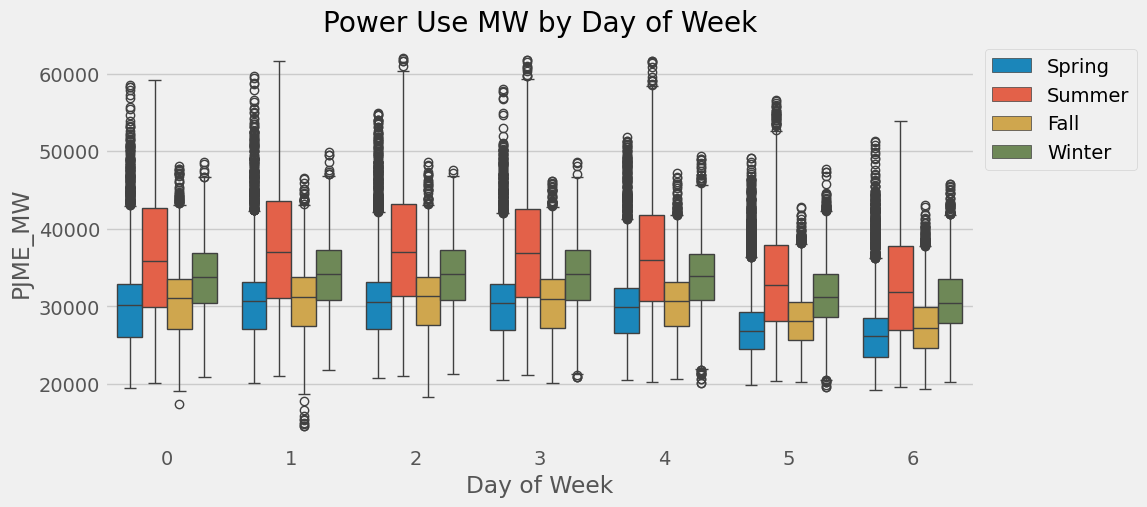

In [66]:
fig, ax = plt.subplots(figsize=(10,5))

sns.boxplot(x="weekday", y="PJME_MW", hue='season',
             ax=ax,
            data=features_and_target)
ax.set_title("Power Use MW by Day of Week")
ax.set_xlabel("Day of Week")
ax.legend(bbox_to_anchor=(1,1))

plt.show()

- We have peaks in winter and summer

In [67]:
# pjme = pjme.reset_index().rename(columns={'Datetime': 'ds', 'PJME_MW': 'y'})

In [68]:
# pjme

In [69]:
pjme.index

DatetimeIndex(['2002-12-31 01:00:00', '2002-12-31 02:00:00',
               '2002-12-31 03:00:00', '2002-12-31 04:00:00',
               '2002-12-31 05:00:00', '2002-12-31 06:00:00',
               '2002-12-31 07:00:00', '2002-12-31 08:00:00',
               '2002-12-31 09:00:00', '2002-12-31 10:00:00',
               ...
               '2018-01-01 15:00:00', '2018-01-01 16:00:00',
               '2018-01-01 17:00:00', '2018-01-01 18:00:00',
               '2018-01-01 19:00:00', '2018-01-01 20:00:00',
               '2018-01-01 21:00:00', '2018-01-01 22:00:00',
               '2018-01-01 23:00:00', '2018-01-02 00:00:00'],
              dtype='datetime64[ns]', name='Datetime', length=145366, freq=None)

# Train/Test Split

In [70]:
split_date = '2015-01-01'
pjme_train = pjme[pjme.index <= split_date]
pjme_test = pjme[pjme.index > split_date]
pjme_train

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0
...,...
2014-01-01 20:00:00,36193.0
2014-01-01 21:00:00,35601.0
2014-01-01 22:00:00,34242.0


In [71]:
pjme_test

,PJME_MW
Datetime,
2015-12-31 01:00:00,24305.0
2015-12-31 02:00:00,23156.0
2015-12-31 03:00:00,22514.0
2015-12-31 04:00:00,22330.0
2015-12-31 05:00:00,22773.0
...,...
2018-01-01 20:00:00,44284.0
2018-01-01 21:00:00,43751.0
2018-01-01 22:00:00,42402.0


<Axes: title={'center': 'PJME'}, xlabel='Datetime'>

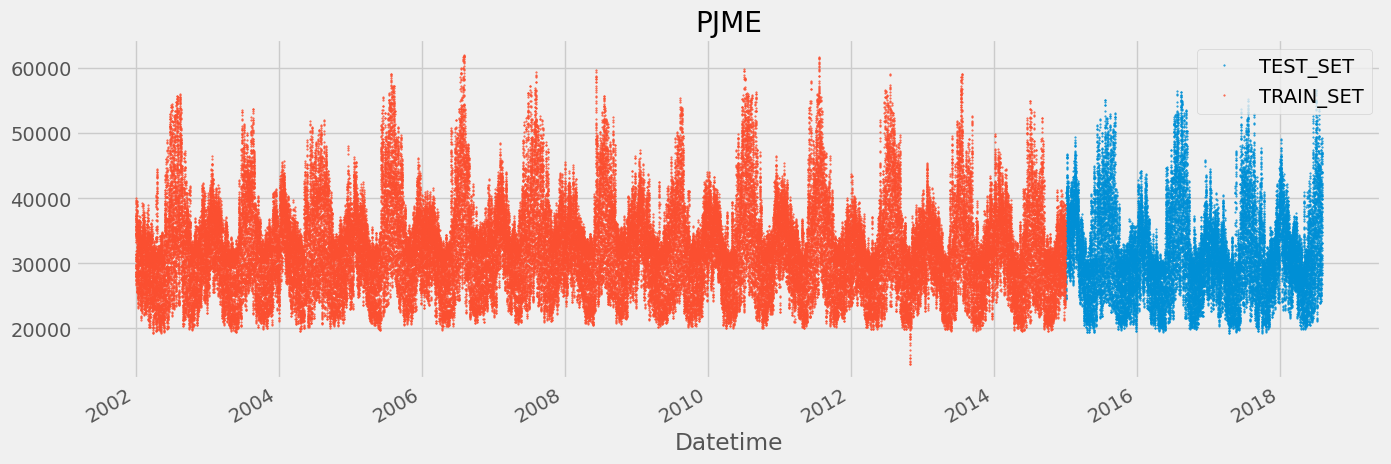

In [72]:
pjme_test.rename(columns={'PJME_MW': 'TEST_SET'}).join(pjme_train.rename(columns={'PJME_MW': 'TRAIN_SET'}), how='outer').plot(figsize=(15,5), title='PJME', style='.', ms=1)

In [73]:
pjme_train = pjme_train.copy().reset_index()
pjme_train.rename(columns={'Datetime': 'ds', 'PJME_MW': 'y'}, inplace=True)

In [74]:
pjme_test = pjme_test.copy().reset_index()
pjme_test.rename(columns={'Datetime': 'ds', 'PJME_MW': 'y'}, inplace=True)

In [75]:
pjme_test[['y']]

,y
0,24305.0
1,23156.0
2,22514.0
3,22330.0
4,22773.0
...,...
31434,44284.0
31435,43751.0
31436,42402.0
31437,40164.0


In [76]:
pjme = pjme.reset_index().rename(columns={'Datetime': 'ds', 'PJME_MW': 'y'})

In [77]:
m = Prophet()

In [78]:
%%time
m.fit(pjme_train)

20:14:46 - cmdstanpy - INFO - Chain [1] start processing
20:15:31 - cmdstanpy - INFO - Chain [1] done processing


CPU times: user 1.85 s, sys: 108 ms, total: 1.95 s
Wall time: 47.2 s


In [79]:
forecasted = m.predict(pjme_test[['ds']])

In [80]:
forecasted[['ds', 'yhat']]

,ds,yhat
0,2015-01-01 01:00:00,28317.084331
1,2015-01-01 02:00:00,26812.550473
2,2015-01-01 03:00:00,25940.778583
3,2015-01-01 04:00:00,25799.259851
4,2015-01-01 05:00:00,26473.661334
...,...,...
31434,2018-08-02 20:00:00,41378.574616
31435,2018-08-02 21:00:00,40605.822655
31436,2018-08-02 22:00:00,38976.713929
31437,2018-08-02 23:00:00,36769.060238


In [81]:
forecasted = forecasted.merge(pjme)
forecasted[['yhat', 'y']]

,yhat,y
0,28317.084331,31647.0
1,26812.550473,30755.0
2,25940.778583,30189.0
3,25799.259851,29890.0
4,26473.661334,30075.0
...,...,...
31440,41378.574616,44057.0
31441,40605.822655,43256.0
31442,38976.713929,41552.0
31443,36769.060238,38500.0


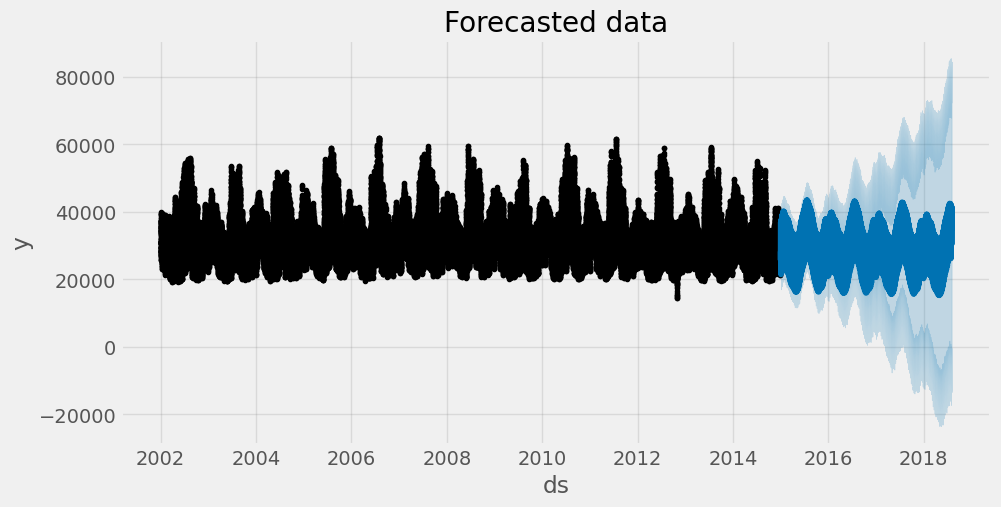

In [82]:
fig, ax = plt.subplots(figsize=(10, 5))
fig1 = m.plot(forecasted, ax=ax)
ax.set_title("Forecasted data")
plt.show()

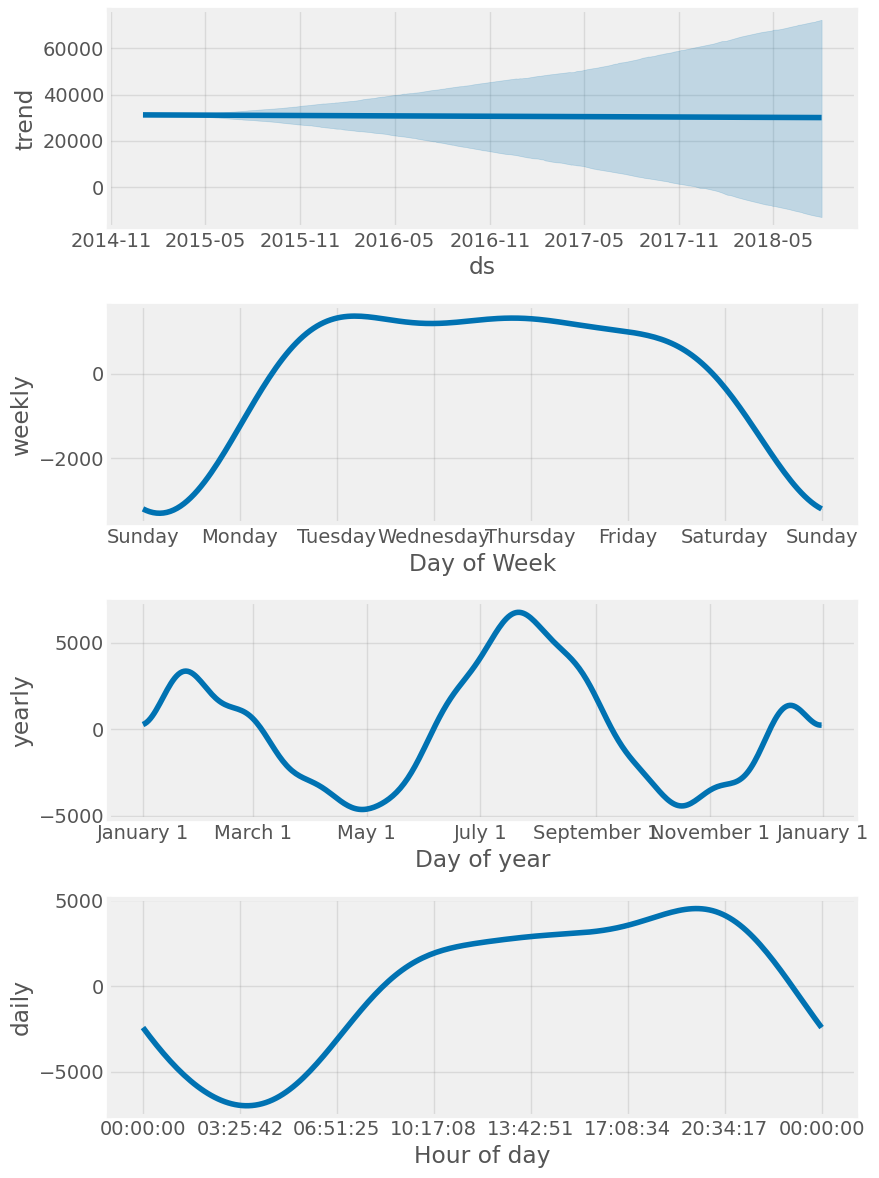

In [83]:
fig2 = m.plot_components(forecasted)

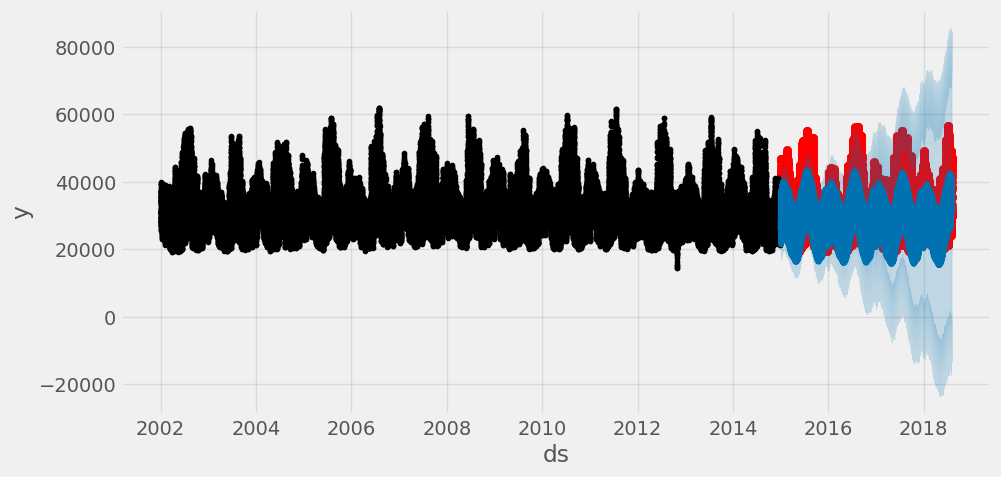

In [84]:
# Plot the forecasted values against the actual values
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(pjme_test['ds'], pjme_test['y'], color='r')
fig =  m.plot(forecasted, ax=ax)
plt.show()

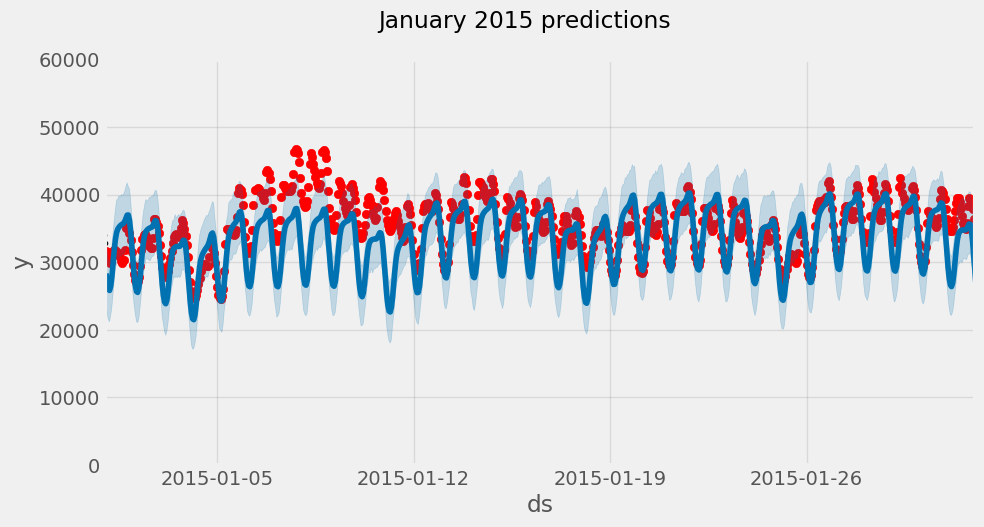

In [85]:
# See comparison in the first month of the forecast
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(pjme_test['ds'], pjme_test['y'], color='r')
fig = m.plot(forecasted,ax=ax)
ax.set_xbound(lower=pd.Timestamp('2015-01-01'),upper=pd.Timestamp('2015-02-01'))
ax.set_ylim(0, 60000)
plt = plt.suptitle("January 2015 predictions")

In [93]:
import matplotlib.pyplot as plt 

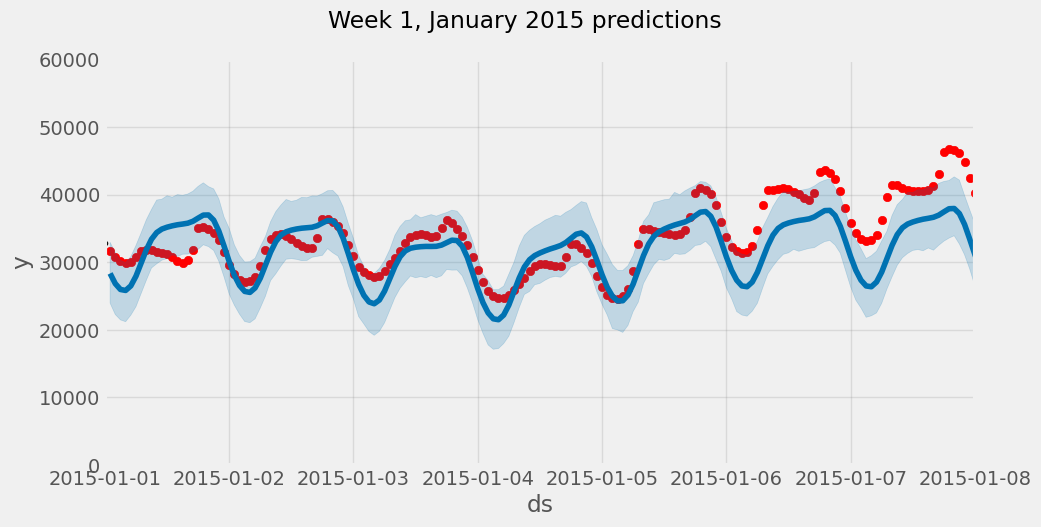

In [87]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(pjme_test['ds'], pjme_test['y'], color='r')
fig = m.plot(forecasted,ax=ax)
ax.set_xbound(lower=pd.Timestamp('2015-01-01'),upper=pd.Timestamp('2015-01-08'))
ax.set_ylim(0, 60000)
plt = plt.suptitle("Week 1, January 2015 predictions")

# Error Metrics

In [88]:
mean_absolute_percentage_error(forecasted['y'], forecasted['yhat']) #91% accuracy

np.float64(9.627486509716306)

In [89]:
root_mean_squared_log_error(forecasted['y'], forecasted['yhat'])

0.12625190383122223

# Data Cleaning

- In the train dataset, there is a drop around 2014. remove it

In [90]:
pjme_train.set_index('ds', inplace=True)

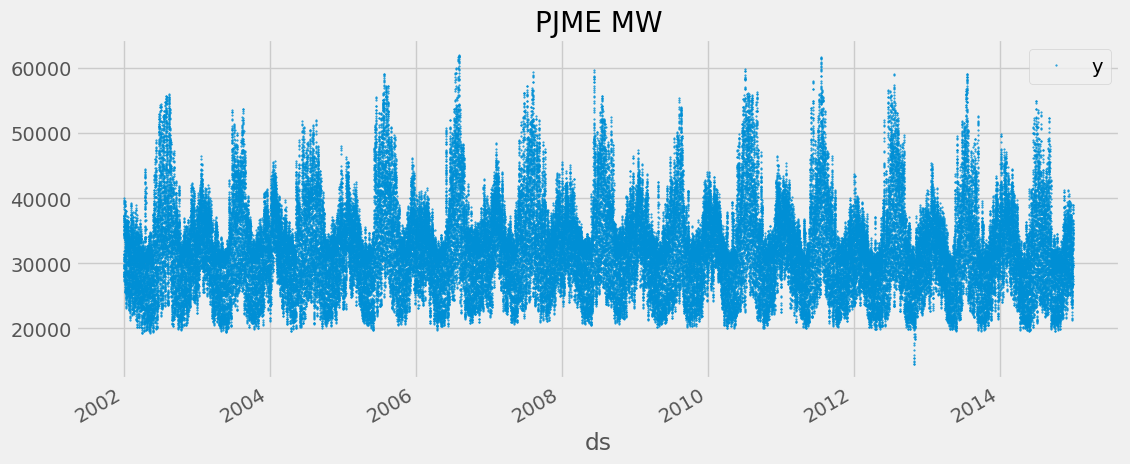

In [94]:
pjme_train.plot(figsize=(12,5), style='.', ms=1, title="PJME MW")
plt.show()

In [102]:
noise = np.where(pjme_train < 18000)[0]
noise
# pjme_train.drop(index=)

array([89114, 89115, 89116, 89117, 89156, 89157])

In [103]:
pjme_train.reset_index(inplace=True)

In [104]:
pjme_train.drop(index=noise, inplace=True)

In [105]:
pjme_train

,ds,y
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0
...,...,...
113918,2014-01-01 20:00:00,36193.0
113919,2014-01-01 21:00:00,35601.0
113920,2014-01-01 22:00:00,34242.0
113921,2014-01-01 23:00:00,32215.0


In [106]:
pjme_train.set_index('ds', inplace=True)

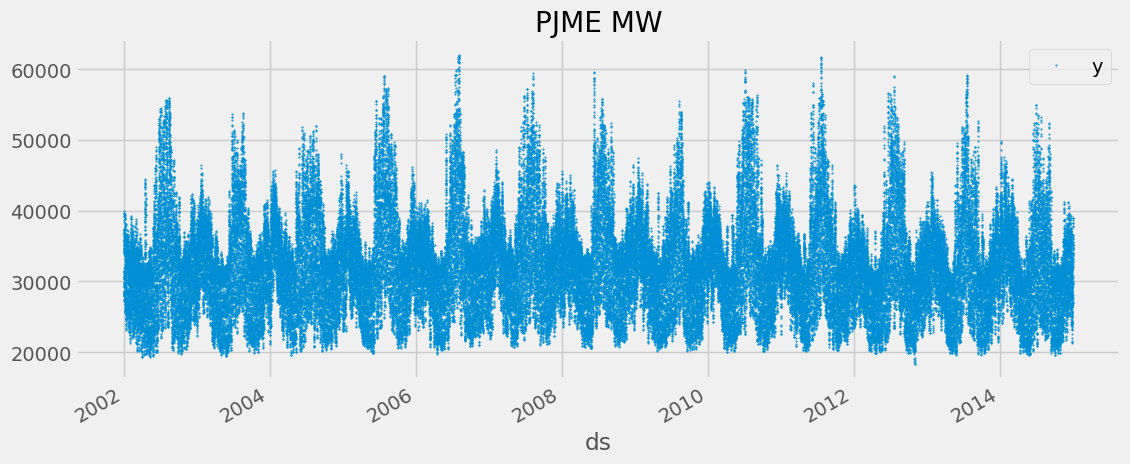

In [107]:
pjme_train.plot(figsize=(12,5), style='.', ms=1, title="PJME MW")
plt.show()

In [108]:
pjme_train.reset_index(inplace=True)

# Re-train model with cleaned trained data

In [109]:
m = Prophet()
m.fit(pjme_train)

20:17:31 - cmdstanpy - INFO - Chain [1] start processing
20:18:45 - cmdstanpy - INFO - Chain [1] done processing


In [110]:
forecasted = m.predict(pjme_test[['ds']])
forecasted = forecasted[['ds', 'yhat']]
forecasted

,ds,yhat
0,2015-01-01 01:00:00,28376.486858
1,2015-01-01 02:00:00,26871.781334
2,2015-01-01 03:00:00,25999.724938
3,2015-01-01 04:00:00,25858.237763
4,2015-01-01 05:00:00,26533.077223
...,...,...
31434,2018-08-02 20:00:00,41296.525153
31435,2018-08-02 21:00:00,40523.853893
31436,2018-08-02 22:00:00,38895.231644
31437,2018-08-02 23:00:00,36688.319217


In [111]:
forecasted = forecasted.merge(pjme)
forecasted

,ds,yhat,y
0,2015-01-01 01:00:00,28376.486858,31647.0
1,2015-01-01 02:00:00,26871.781334,30755.0
2,2015-01-01 03:00:00,25999.724938,30189.0
3,2015-01-01 04:00:00,25858.237763,29890.0
4,2015-01-01 05:00:00,26533.077223,30075.0
...,...,...,...
31440,2018-08-02 20:00:00,41296.525153,44057.0
31441,2018-08-02 21:00:00,40523.853893,43256.0
31442,2018-08-02 22:00:00,38895.231644,41552.0
31443,2018-08-02 23:00:00,36688.319217,38500.0


In [112]:
mean_absolute_percentage_error(forecasted['yhat'], forecasted['y'])

np.float64(10.191366076834834)

- Removing the noise doesn't really help our model